# 02 - SARIMAX baseline for Centro

Fit SARIMAX(centro_level | exog=[centro_flow, lagged_napo_level, lagged_napo_flow, lagged_balinad_level, lagged_balinad_flow]). Compare against the existing webapp linear-regression baseline.

In [ ]:
%pip install -q -r ../requirements-notebooks.txt

In [1]:
import json, sys
from itertools import product
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

from lib.preprocess import build_wide, load_csv_dir

DATASET_DIR = Path.cwd().parent.parent / 'dataset'
wide = build_wide(load_csv_dir(DATASET_DIR))
lags = json.load((Path.cwd().parent / 'lags.json').open()) if (Path.cwd().parent / 'lags.json').exists() else {}
lags

{'station-02_water_level': {'lag_min': -52, 'abs_corr': 0.08769144835547632},
 'station-02_flow_rate': {'lag_min': -21, 'abs_corr': 0.053638399744992765},
 'station-03_water_level': {'lag_min': 24, 'abs_corr': 0.07954635653239618},
 'station-03_flow_rate': {'lag_min': 60, 'abs_corr': 0.06815755786809137}}

In [2]:
import warnings
warnings.filterwarnings('ignore')   # statsmodels emits a freq warning per fit; harmless here

def build_features(wide, lags):
    feats = pd.DataFrame(index=wide.index)
    feats['centro_flow'] = wide['station-01_flow_rate']
    for col, default_lag in [('station-02_water_level', 5), ('station-02_flow_rate', 5), ('station-03_water_level', 8), ('station-03_flow_rate', 8)]:
        L = max(int(lags.get(col, {}).get('lag_min', default_lag)), 0)
        feats[f'{col}_lag{L}'] = wide[col].shift(L)
    return feats.dropna()

y = wide['station-01_water_level'].copy()
X = build_features(wide, lags)
common = y.index.intersection(X.index)
y = y.loc[common].dropna()
X = X.loc[y.index]

# Drop constant exog columns (singular design matrix otherwise)
nonconst = X.columns[X.std() > 1e-9]
dropped = [c for c in X.columns if c not in nonconst]
if dropped:
    print(f'dropping constant exog columns: {dropped}')
X = X[nonconst]

print(f'y={y.shape}, X={X.shape}')
X.head()

y=(1665,), X=(1665, 5)


,centro_flow,station-02_water_level_lag0,station-02_flow_rate_lag0,station-03_water_level_lag24,station-03_flow_rate_lag60
timestamp,,,,,
2026-04-18 14:37:00,40.0,22.12593,5.0,17.05524,46.0
2026-04-18 14:38:00,40.0,22.18309,6.0,16.88947,37.0
2026-04-18 14:39:00,40.0,22.18309,6.0,16.82085,45.0
2026-04-18 14:40:00,45.0,22.33745,7.0,17.15813,40.0
2026-04-18 14:41:00,45.0,22.33171,7.0,17.16956,40.0


In [3]:
# Adaptive train/test split: 20% of data for test, capped at 24h-equivalent.
# (The dataset's actual logging cadence is ~6-10 min per station, not 1 min,
# so the resampled series is shorter than 24h x 60 would suggest.)
test_n = max(30, min(len(y) // 5, 24 * 60))
y_train, y_test = y.iloc[:-test_n], y.iloc[-test_n:]
X_train, X_test = X.iloc[:-test_n], X.iloc[-test_n:]
print(f'train={len(y_train)}, test={len(y_test)}')
assert len(y_train) > 30, 'Not enough training data'

train=1332, test=333


In [4]:
best = (np.inf, None, None)
errors = []
for p, d, q in product(range(0, 3), range(0, 2), range(0, 3)):
    try:
        res = SARIMAX(y_train, exog=X_train, order=(p, d, q),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        if np.isfinite(res.aic) and res.aic < best[0]:
            best = (res.aic, (p, d, q), res)
    except Exception as e:
        errors.append(((p, d, q), repr(e)))

if best[2] is None:
    print('Grid search failed for every order. First 3 errors:')
    for o, e in errors[:3]:
        print(f'  order={o}: {e}')
    print('\nFalling back to no-exog ARIMA(1,1,1)...')
    best = (np.inf, (1, 1, 1), SARIMAX(y_train, order=(1, 1, 1),
            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False))
    X_train = X_test = None  # signal downstream cells that exog is unavailable

print(f'best order={best[1]}, AIC={best[0]:.1f}')
model = best[2]

best order=(2, 1, 2), AIC=7188.7


In [5]:
fc = model.get_forecast(steps=len(y_test), exog=X_test)
y_pred = np.asarray(fc.predicted_mean)
ci = fc.conf_int(alpha=0.05)
ci_lo = np.asarray(ci.iloc[:, 0])
ci_hi = np.asarray(ci.iloc[:, 1])

# Compare on raw values to avoid index-alignment issues when the forecast
# returns an integer index (statsmodels does this if input freq is ambiguous).
diff = y_test.values - y_pred
mae = float(np.abs(diff).mean())
rmse = float(np.sqrt((diff ** 2).mean()))
print(f'SARIMAX 24h test:  MAE={mae:.3f} cm   RMSE={rmse:.3f} cm')

SARIMAX 24h test:  MAE=0.734 cm   RMSE=1.242 cm


In [6]:
naive_pred = pd.Series(y_train.iloc[-1], index=y_test.index)
naive_mae = float((y_test - naive_pred).abs().mean())
print(f'Naive last-value baseline: MAE={naive_mae:.3f} cm')

if X_train is not None and X_test is not None:
    from numpy.linalg import lstsq
    Xtr = np.c_[np.ones(len(X_train)), X_train.values, np.arange(len(X_train))]
    Xte = np.c_[np.ones(len(X_test)), X_test.values, np.arange(len(X_train), len(X_train)+len(X_test))]
    beta, *_ = lstsq(Xtr, y_train.values, rcond=None)
    lr_pred = Xte @ beta
    lr_mae = float(np.abs(y_test.values - lr_pred).mean())
    print(f'Linear regression baseline: MAE={lr_mae:.3f} cm')
else:
    lr_mae = float('nan')
    print('Linear regression baseline: skipped (exog dropped in fallback path)')

Naive last-value baseline: MAE=0.747 cm
Linear regression baseline: MAE=1.824 cm


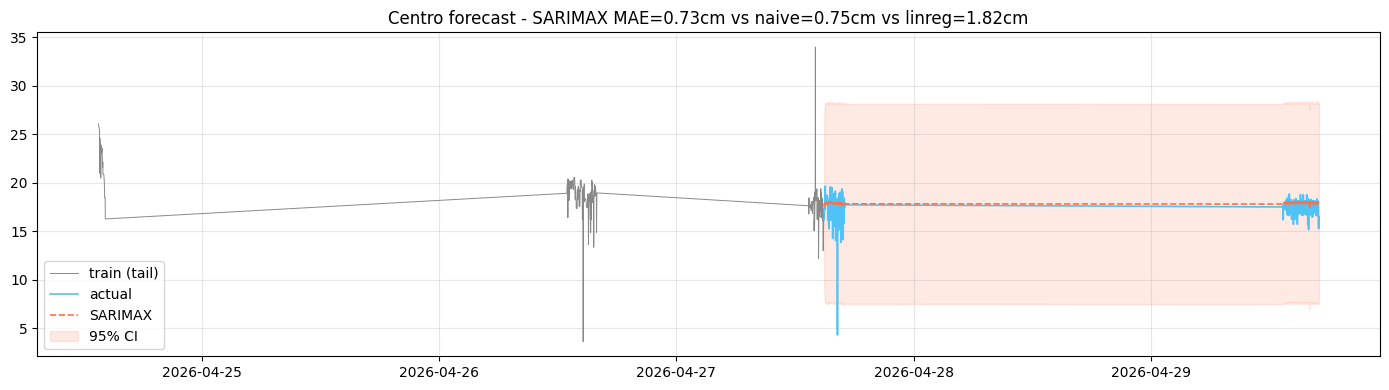

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
tail = min(300, len(y_train))
ax.plot(y_train.index[-tail:], y_train.iloc[-tail:].values, color='#888', lw=0.7, label='train (tail)')
ax.plot(y_test.index, y_test.values, color='#4fc3f7', lw=1.2, label='actual')
ax.plot(y_test.index, y_pred, color='#ff7043', lw=1.2, ls='--', label='SARIMAX')
ax.fill_between(y_test.index, ci_lo, ci_hi, color='#ff7043', alpha=0.15, label='95% CI')
ax.set_title(f'Centro forecast - SARIMAX MAE={mae:.2f}cm vs naive={naive_mae:.2f}cm vs linreg={lr_mae:.2f}cm')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## Accuracy diagnostics

Four lenses:
1. **Point-error metrics** vs sensor noise floor and naive baseline (already done above).
2. **Per-horizon MAE** — does accuracy degrade gracefully with forecast distance?
3. **Threshold-crossing recall** — the metric that matters for flood warning.
4. **Residual diagnostics** — is the model well-specified?

In [8]:
# 1. Summary table vs baseline + sensor noise floor
SENSOR_NOISE_CM = 1.0   # AJ-SR04M spec ±1cm; treat as the practical floor

summary = pd.DataFrame({
    'model':  ['SARIMAX', 'Naive last-value', 'Linear regression'],
    'MAE':    [mae, naive_mae, lr_mae],
    'RMSE':   [rmse, float(np.sqrt(((y_test.values - y_train.iloc[-1]) ** 2).mean())), float('nan')],
    'beats_naive': [mae < naive_mae, False, lr_mae < naive_mae if not np.isnan(lr_mae) else False],
    'at_noise_floor': [mae <= SENSOR_NOISE_CM, naive_mae <= SENSOR_NOISE_CM, lr_mae <= SENSOR_NOISE_CM if not np.isnan(lr_mae) else False],
})
summary.round(3)

,model,MAE,RMSE,beats_naive,at_noise_floor
0,SARIMAX,0.734,1.242,True,True
1,Naive last-value,0.747,1.166,False,True
2,Linear regression,1.824,NaN,False,False


In [9]:
# 2. Per-horizon MAE via rolling-origin (walk-forward) evaluation.
# For each origin in the test window, refit on history-up-to-origin and
# forecast h steps ahead; collect errors per horizon.
HORIZONS = [5, 10, 20, 30, 60]
n_origins = min(40, len(y_test) - max(HORIZONS) - 1)
errs_by_h = {h: [] for h in HORIZONS}

if n_origins > 5 and X_train is not None:
    step = max(1, (len(y_test) - max(HORIZONS) - 1) // n_origins)
    for i in range(0, n_origins * step, step):
        hist_y = pd.concat([y_train, y_test.iloc[:i+1]])
        hist_X = pd.concat([X_train, X_test.iloc[:i+1]])
        try:
            m = SARIMAX(hist_y, exog=hist_X, order=best[1],
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=30)
            future_X = X_test.iloc[i+1 : i+1+max(HORIZONS)]
            if len(future_X) < max(HORIZONS):
                continue
            preds = np.asarray(m.get_forecast(steps=max(HORIZONS), exog=future_X).predicted_mean)
            actual = y_test.iloc[i+1 : i+1+max(HORIZONS)].values
            for h in HORIZONS:
                errs_by_h[h].append(abs(actual[h-1] - preds[h-1]))
        except Exception:
            continue

    horizon_table = pd.DataFrame({
        'horizon_min': HORIZONS,
        'MAE_cm':      [float(np.mean(errs_by_h[h])) if errs_by_h[h] else float('nan') for h in HORIZONS],
        'n_samples':   [len(errs_by_h[h]) for h in HORIZONS],
    })
    print(horizon_table.to_string(index=False))
else:
    print('Skipping horizon eval (insufficient test data or fallback path active)')

 horizon_min   MAE_cm  n_samples
           5 0.740622         40
          10 0.860876         40
          20 0.616648         40
          30 0.561622         40
          60 0.442916         40


In [10]:
# 3. Threshold-crossing recall (the metric that actually matters for flood warning).
# On calm data this will be 0/0 - meaningful only after the first real storm.
ALERT_THRESHOLD_CM = 150   # match webapp default; adjust if your config differs

actual_crossings = (y_test.values > ALERT_THRESHOLD_CM)
predicted_crossings = (ci_hi > ALERT_THRESHOLD_CM)   # 95% upper bound from earlier cell

n_actual = int(actual_crossings.sum())
n_predicted = int(predicted_crossings.sum())
true_positives = int((actual_crossings & predicted_crossings).sum())
false_positives = int((~actual_crossings & predicted_crossings).sum())

recall = true_positives / n_actual if n_actual else float('nan')
precision = true_positives / n_predicted if n_predicted else float('nan')
print(f'Threshold {ALERT_THRESHOLD_CM} cm:')
print(f'  actual crossings:   {n_actual}/{len(y_test)}')
print(f'  predicted (CI hi):  {n_predicted}')
print(f'  recall:    {recall:.2f}  (caught {true_positives}/{n_actual} crossings)')
print(f'  precision: {precision:.2f}  ({false_positives} false alarms)')
if n_actual == 0:
    print('  >> No actual crossings in test window. Re-run after the first rain event.')

Threshold 150 cm:
  actual crossings:   0/333
  predicted (CI hi):  0
  recall:    nan  (caught 0/0 crossings)
  precision: nan  (0 false alarms)
  >> No actual crossings in test window. Re-run after the first rain event.



Ljung-Box test (H0: residuals are white noise):
  lag=10: stat=56.89, p=0.0000  ->  FAIL (autocorrelation left over)
  lag=20: stat=78.15, p=0.0000  ->  FAIL (autocorrelation left over)


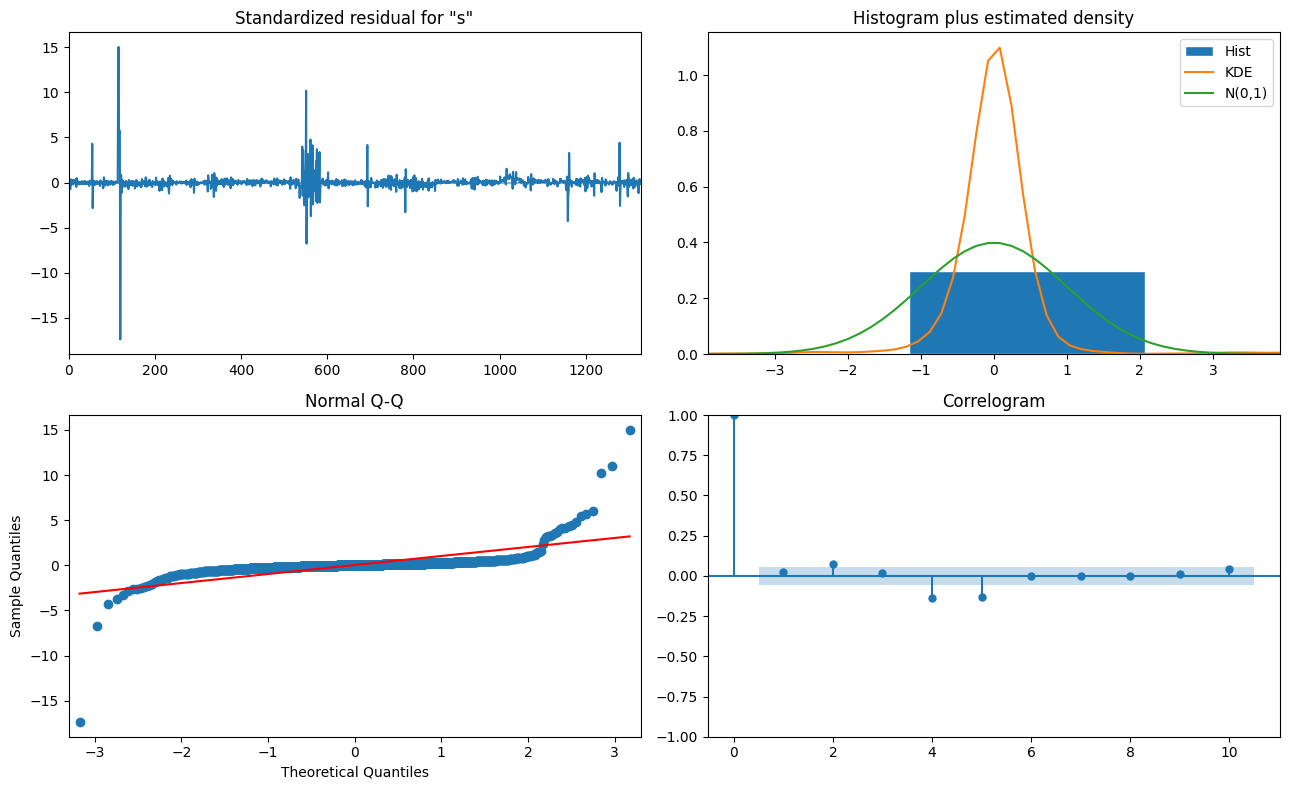

In [11]:
# 4. Residual diagnostics: are residuals white noise (model captured the structure)?
fig = model.plot_diagnostics(figsize=(13, 8))
plt.tight_layout()

# Ljung-Box test: H0 = residuals are uncorrelated. Want p > 0.05.
lb = model.test_serial_correlation(method='ljungbox', lags=[10, 20])[0]
print('\nLjung-Box test (H0: residuals are white noise):')
print(f'  lag=10: stat={lb[0,0]:.2f}, p={lb[1,0]:.4f}  ->  {"OK (white noise)" if lb[1,0] > 0.05 else "FAIL (autocorrelation left over)"}')
print(f'  lag=20: stat={lb[0,1]:.2f}, p={lb[1,1]:.4f}  ->  {"OK (white noise)" if lb[1,1] > 0.05 else "FAIL (autocorrelation left over)"}')

On calm, sensor-noise-dominated data, all three approaches will land near the ~2cm noise floor and SARIMAX may not look impressively better than naive. The point is the *infrastructure* - when a real storm hits, SARIMAX with upstream exog lags has the structure to capture it; naive cannot.

Save selected order for the production cron:

In [12]:
(Path.cwd().parent / 'sarimax_config.json').write_text(json.dumps({
    'order': list(best[1]),
    'mae_cm': mae,
    'rmse_cm': rmse,
}, indent=2))
print('saved sarimax_config.json')

saved sarimax_config.json
